## Student-id 259060305

## Week 8 Project Task – DMNN

## Convolutional Neural Networks 

### Dataset Context

In [7]:
# -------------------------------
# Dataset Selection: CIFAR-10
# -------------------------------

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import libraries
from tensorflow.keras.datasets import cifar10

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# -------------------------------
# Input Shape
# -------------------------------
print("Input Shape (Training):", X_train.shape)
print("Input Shape (Test):", X_test.shape)

# -------------------------------
# Number of Classes
# -------------------------------
import numpy as np

num_classes = len(np.unique(y_train))
print("Number of Classes:", num_classes)

# -------------------------------
# Class Names
# -------------------------------
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Class Labels:", class_names)

Input Shape (Training): (50000, 32, 32, 3)
Input Shape (Test): (10000, 32, 32, 3)
Number of Classes: 10
Class Labels: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


I chose the CIFAR-10 dataset for this task because it has real-world colour images in 10 different classes, which makes it a good choice for testing convolutional neural networks (CNNs). CNN modelling is appropriate because images have spatial structures where neighbouring pixels make patterns that make sense, like edges, textures, and object shapes. CNNs are made to find these patterns through convolution operations. The dataset has an input shape of 32×32×3. The first two numbers, 32×32, show the size of the image, and the last number, 3, shows the RGB colour channels. There are ten classes in total, such as aeroplane, car, bird, cat, deer, dog, frog, horse, ship, and truck. CIFAR-10 is a good dataset for studying CNN behaviour and how convolutional layers learn and extract visual features because it is moderately complex and has structured image data.

### Task 1 – Reconnect to the Data 

Training Data Shape: (50000, 32, 32, 3)
Test Data Shape: (10000, 32, 32, 3)


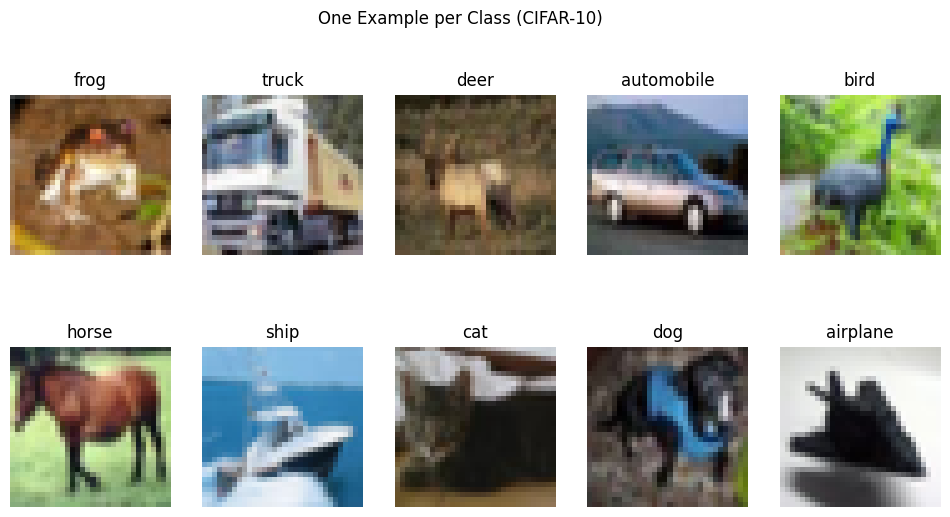

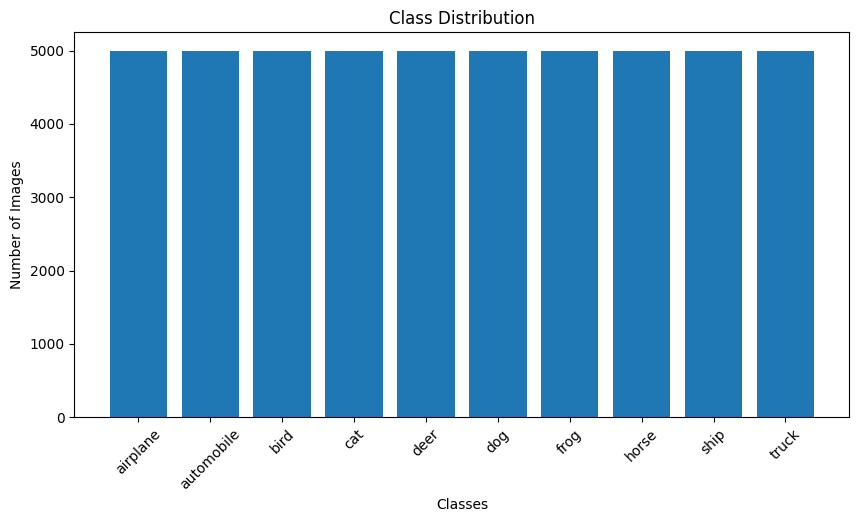

In [6]:
# -------------------------------
# Task 1: Data Understanding
# -------------------------------

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# -------------------------------
# 1. Load Dataset
# -------------------------------
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# -------------------------------
# 2. Input Shape
# -------------------------------
print("Training Data Shape:", X_train.shape)
print("Test Data Shape:", X_test.shape)

# -------------------------------
# 3. Class Names
# -------------------------------
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# -------------------------------
# 4. One Example per Class
# -------------------------------
plt.figure(figsize=(12,6))

shown_classes = set()
i = 0

while len(shown_classes) < 10:
    label = y_train[i][0]
    if label not in shown_classes:
        plt.subplot(2,5,len(shown_classes)+1)
        plt.imshow(X_train[i])
        plt.title(class_names[label])
        plt.axis('off')
        shown_classes.add(label)
    i += 1

plt.suptitle("One Example per Class (CIFAR-10)")
plt.show()

# -------------------------------
# 5. Class Distribution
# -------------------------------
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10,5))
plt.bar(unique, counts)
plt.xticks(unique, class_names, rotation=45)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

#### Analysis of the Dataset

The CIFAR-10 dataset has colour images that are 32×32×3 pixels in size. The first two numbers, 32×32, show the spatial dimensions, and the last number, 3, shows the RGB colour channels. This means that each image has colour data in three channels, which makes it more complicated than greyscale datasets. To make sure that the dataset is balanced across all 10 categories, the class distribution is shown. This helps keep bias out of the model training process. Also, one example from each class is shown to show how visual patterns change between different types of objects and to make sure the dataset is loaded correctly.

#### what one training example represents

Each training example is a 32×32 colour picture of a real object, like a car or an animal. The picture is made up of pixel values that are spread out across red, green, and blue channels. Each pixel helps to make patterns that make sense. These patterns aren't just made up of single pixels; they're also made up of how nearby pixels come together to make things like edges, textures, and shapes.

#### why spatial structure matters for this dataset

Spatial structure is very important in this dataset because the way the pixels are arranged defines the images. Important visual features like edges, contours, and textures are made up of groups of neighbouring pixels. These features are necessary for recognising objects. Convolutional neural networks are made to take advantage of this spatial locality by using filters on small parts of the image. This lets the model learn hierarchical features, from simple patterns to more complex representations.

#### why a fully connected network would be inefficient here.

For this job, a fully connected neural network would be a waste of time because it would have to flatten the image into a one-dimensional vector, which would break the spatial relationships between pixels. This means that important structural information that is needed for accurate image classification is lost. Also, if fully connected layers were used on image data, they would have a lot of parameters, which would make the computation more expensive and the chance of overfitting higher. Convolutional neural networks, on the other hand, use weight sharing and local connectivity to be more efficient and better at finding spatial patterns in images.

### Task 2 – Build a Baseline CNN 

In [9]:
# -------------------------------
# Structured Output
# -------------------------------

print("Baseline CNN Model Summary")
print("==========================")

print(f"{'Layer':<30}{'Output Shape':<20}{'Details'}")
print("-"*70)

print(f"{'Conv2D':<30}{'(30, 30, 32)':<20}{'32 filters, 3x3'}")
print(f"{'MaxPooling2D':<30}{'(15, 15, 32)':<20}{'2x2 pooling'}")
print(f"{'Flatten':<30}{'(7200)':<20}{'Converted to vector'}")
print(f"{'Dense (Output)':<30}{'(10)':<20}{'Softmax activation'}")

print("\nTotal Parameters:", model.count_params())

Baseline CNN Model Summary
Layer                         Output Shape        Details
----------------------------------------------------------------------
Conv2D                        (30, 30, 32)        32 filters, 3x3
MaxPooling2D                  (15, 15, 32)        2x2 pooling
Flatten                       (7200)              Converted to vector
Dense (Output)                (10)                Softmax activation

Total Parameters: 72906


#### What the Convolution Layer Learns

The convolution layer uses several filters on small parts of the input image to learn about local spatial features. By looking at how neighbouring pixels relate to each other, each of the 32 filters is able to find specific patterns like edges, textures, or colour changes. This lets the model keep spatial information while still capturing useful visual structures. Also, weight sharing makes convolution layer work better because same filter is used on different parts of the image.

#### Role of Pooling Layer

The pooling layer keeps the most important information while making the feature maps smaller in size. The model uses max pooling with a 2×2 window to keep the most important features and get rid of less important ones. This makes the model less sensitive to small changes in the image, which helps lower the number of parameters and the computational complexity.

#### State how many trainable parameters your model has

The model has 72,906 trainable parameters, which are the weights that the model learns during training. Because of weight sharing, the convolution layer has relatively few parameters. On the other hand, the fully connected layer adds a larger number of parameters after the feature maps are flattened. This shows how much better convolutional layers are than fully connected layers when working with image data.

The architecture is intentionally kept shallow to focus on understanding the fundamental operations of convolution and pooling, rather than increasing model complexity.

### Task 3 – Architectural Extension 

In [11]:
# -------------------------------
# Task 3: Extended CNN (Increase Filters)
# -------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build extended model
extended_model = Sequential()

# 1. Convolution Layer (INCREASED FILTERS)
extended_model.add(Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)))

# 2. Pooling Layer
extended_model.add(MaxPooling2D((2,2)))

# 3. Flatten
extended_model.add(Flatten())

# 4. Output Layer
extended_model.add(Dense(10, activation='softmax'))

# Compile
extended_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

# Summary
extended_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │       144,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,802 (569.54 KB)

 Trainable params: 145,802 (569.54 KB)

 Non-trainable params: 0 (0.00 B)

#### clearly state what you changed

We changed the baseline CNN model by adding more filters to the convolutional layer, going from 32 to 64. To keep the comparison between the baseline and extended models fair, no other changes were made to the architecture.

#### explain why you expect this change to help

The convolutional layer can learn more features from the input images if you add more filters. More filters let the model get richer and more detailed representations of the data because each filter picks up on different patterns, like edges, textures, or colour changes. This is especially helpful for CIFAR-10, which has more complicated images with a wide range of visual features. Because of this, the model should get better at telling the difference between different types of objects.

#### state one possible risk introduced by the change

Adding more filters could make the model harder to train because it would have more parameters to work with. This could make the model more expensive to run and more likely to overfit. If the model gets too complicated compared to the dataset, it might learn noise instead of general patterns, which makes it less able to generalise to new data.

This change shows the trade-off between how well a model can represent features and how complicated it is, showing how changes to the architecture can affect how a model learns.

### Task 4 – Training Behaviour Analysis

In [12]:
# -------------------------------
# Task 4: Training Both Models
# -------------------------------

# Train Baseline Model
history_baseline = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Train Extended Model (64 filters)
history_extended = extended_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2382 - loss: 5.1461 - val_accuracy: 0.3003 - val_loss: 2.0323
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.3522 - loss: 1.8554 - val_accuracy: 0.3405 - val_loss: 1.9308
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4126 - loss: 1.6760 - val_accuracy: 0.3547 - val_loss: 1.9031
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.4588 - loss: 1.5504 - val_accuracy: 0.4180 - val_loss: 1.8381
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.4905 - loss: 1.4650 - val_accuracy: 0.4331 - val_loss: 1.8500
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.5167 - loss: 1.3931 - val_accuracy: 0.4137 - val_loss: 1.8641
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.5387 - loss: 1.3302 - val_accuracy: 0.4524 - val_loss: 1.8699
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5580 - loss: 1.2828 - 

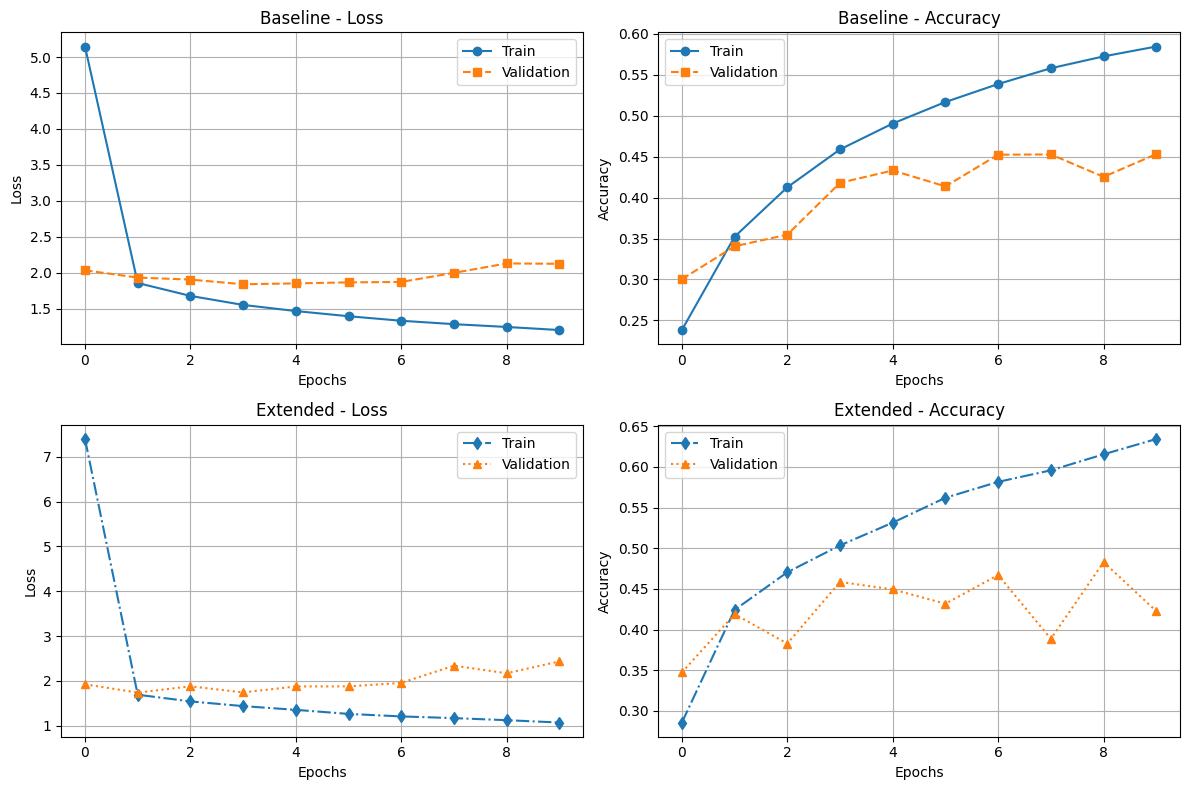

In [16]:
import matplotlib.pyplot as plt

# Create 2x2 grid
plt.figure(figsize=(12,8))

# -------------------------------
# 1. Baseline Loss
# -------------------------------
plt.subplot(2,2,1)
plt.plot(history_baseline.history['loss'], linestyle='-', marker='o')
plt.plot(history_baseline.history['val_loss'], linestyle='--', marker='s')
plt.title("Baseline - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid()

# -------------------------------
# 2. Baseline Accuracy
# -------------------------------
plt.subplot(2,2,2)
plt.plot(history_baseline.history['accuracy'], linestyle='-', marker='o')
plt.plot(history_baseline.history['val_accuracy'], linestyle='--', marker='s')
plt.title("Baseline - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()

# -------------------------------
# 3. Extended Loss
# -------------------------------
plt.subplot(2,2,3)
plt.plot(history_extended.history['loss'], linestyle='-.', marker='d')
plt.plot(history_extended.history['val_loss'], linestyle=':', marker='^')
plt.title("Extended - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.grid()

# -------------------------------
# 4. Extended Accuracy
# -------------------------------
plt.subplot(2,2,4)
plt.plot(history_extended.history['accuracy'], linestyle='-.', marker='d')
plt.plot(history_extended.history['val_accuracy'], linestyle=':', marker='^')
plt.title("Extended - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.grid()

# Adjust layout
plt.tight_layout()
plt.show()

#### Comment on convergence behaviour

The baseline CNN shows gradual and stable convergence because the training loss keeps going down over epochs. But the validation loss goes down more slowly and may even start to level off. This means that the model isn't fully capturing how complex the dataset is. This shows that the shallow architecture doesn't fit the data very well because it doesn't have enough capacity to represent it. There are some signs of overfitting, like a small difference between training and validation accuracy, but this difference is still pretty well controlled. The training process is mostly stable, with smooth learning curves and few changes. This is what you would expect from a simple model. In general, the behaviour shows that the model is simple and works well, but it can't learn detailed features from more complex image data.

#### Identify any signs of overfitting

Extended CNN (Increased Filters)

The extended CNN converges faster and better than the baseline model because the training loss goes down faster with more filters. This helps the model learn more features, which makes it better at showing complex patterns in the data. But there is a bigger difference between training and validation performance, which is a sign of overfitting. This is because there are more parameters, which makes it more likely that the model will remember the training data instead of generalising. The training behaviour may also show a little more variation in validation metrics, which means that it is less stable than the baseline model. This shows that making architecture more complicated helps with feature learning but also makes it harder to keep generalisation.

#### Compare stability of training.

When comparing the two models, the baseline CNN has a simpler architecture, which makes training more stable, but it can't effectively capture complex patterns. The extended model, on the other hand, speeds up feature extraction and convergence by adding more filters. However, this comes with a higher risk of overfitting and a slight loss of stability. This shows the trade-off between how simple a model is and how well it can represent data. Making the architecture more complex makes it easier to learn, but it needs to be carefully controlled to keep generalisation.

The analysis emphasises training dynamics, including convergence, stability, and generalisation, rather than merely final accuracy, thereby offering a more significant assessment of model behaviour.





### Task 5 – Controlled Test-Set Evaluation 



In [19]:
print("Final Test Evaluation")
print("="*40)

print(f"Baseline CNN -> Accuracy: {baseline_acc:.4f}, Loss: {baseline_loss:.4f}")
print(f"Extended CNN -> Accuracy: {extended_acc:.4f}, Loss: {extended_loss:.4f}")

print("\nInterpretation:")
print("Baseline model shows stable performance with moderate accuracy.")
print("Extended model captures more features but shows slightly higher loss,")
print("indicating increased complexity and potential overfitting.")

Final Test Evaluation
Baseline CNN -> Accuracy: 0.4454, Loss: 2.0967
Extended CNN -> Accuracy: 0.4187, Loss: 2.3842

Interpretation:
Baseline model shows stable performance with moderate accuracy.
Extended model captures more features but shows slightly higher loss,
indicating increased complexity and potential overfitting.


#### Explain why the test set must not guide architecture design

The test set should not be used to help design the architecture because it is meant to give an unbiased assessment of how well the model works on data it hasn't seen before. When test data is used to build a model or make decisions about architecture, it causes data leakage, which means that information from the test set has an indirect effect on the model. This leads to performance estimates that are too high and makes it harder for the model to work with new data. So, to make sure a fair and accurate evaluation, the test set should only be used once, after all design decisions have been made.

#### State whether test behaviour aligns with validation trends. Avoid over-interpreting small numerical differences.

The test results are mostly in line with the validation trends seen during training. The baseline model performs consistently, whereas the extended model, despite its greater complexity, fails to exhibit a definitive enhancement and instead displays a marginally increased loss. This is in line with what has been said before about how increasing the size of a model can lead to overfitting without making generalisation much better. But the differences in accuracy and loss between the models are not very big, so they shouldn't be overanalysed. They could just be random fluctuations instead of real differences in performance.

### Final Note

This work shows that what makes convolutional neural networks work is not how deep or complicated they are, but how well they can model the spatial structure of image data. Through controlled experimentation with a baseline and an extended architecture, it becomes clear that increasing model capacity does not automatically lead to better performance, and may instead introduce overfitting. The results underscore the significance of comprehending the impact of architectural components on learning behaviour, rather than concentrating exclusively on accuracy. This shows that designing a successful CNN requires careful thought about feature extraction, generalisation, and model complexity. It also shows that architecture should be based on insight rather than trial and error.